In [5]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
def g_kernel(x, mean, sigma):
    return torch.exp(-(x-mean)@(x-mean)/(2*sigma**2))

patch_size = 8
half_hsize = int(patch_size/2)

h = np.empty((2, patch_size, patch_size))
for i in range( patch_size):
    for j in range( patch_size):
        h[:,i,j] = (i,j)

gh = torch.empty(h.shape[1:])
for i in range(h.shape[1]):
    for j in range(h.shape[2]):
        gh[i,j]= g_kernel(torch.from_numpy(h[:,i,j]).to(dtype=torch.float), half_hsize, 8)

h_sum = torch.sum(gh)
W = gh.unsqueeze(0).unsqueeze(0)

In [2]:
# define smoothing convolution weights, store them in params

factor = 8
h_size = factor
half_hsize = int(h_size/2)
h = np.empty((2, h_size,h_size))
for i in range(h_size):
    for j in range(h_size):
        h[:,i,j] = (i,j)
mean = torch.ones(2,dtype = torch.float)*half_hsize
sigma = factor#/4
gh = torch.empty(h.shape[1:])
for i in range(h.shape[1]):
    for j in range(h.shape[2]):
        gh[i,j]= g_kernel(torch.from_numpy(h[:,i,j]).to(dtype=torch.float), mean, sigma)
gh = gh/torch.sum(gh)
params['C_W'] = gh.unsqueeze(0).unsqueeze(0) 

NameError: name 'params' is not defined

In [6]:

params = {}
h_size =  4
half_hsize = int(h_size/2)
h = np.empty((2, h_size,h_size))
for i in range(h_size):
    for j in range(h_size):
        h[:,i,j] = (i,j)
mean = torch.ones(2,dtype = torch.float)*half_hsize
sigma = 8
gh = torch.empty(h.shape[1:])
for i in range(h.shape[1]):
    for j in range(h.shape[2]):
        gh[i,j]= g_kernel(torch.from_numpy(h[:,i,j]).to(dtype=torch.float), mean, sigma)
gh = gh/torch.sum(gh)
params['smoothing_W'] = gh.unsqueeze(0).unsqueeze(0)

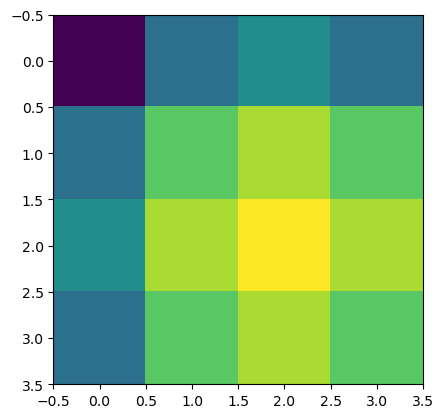

In [7]:
plt.imshow(params['smoothing_W'][0,0,:,:])

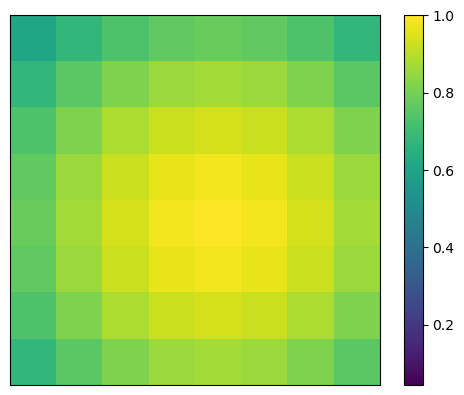

In [8]:
import matplotlib.pyplot as plt
plt.imshow(W[0,0,:,:]*W[0,0,:,:],  vmax = 1, vmin = 0.0439)
plt.xticks([])
plt.yticks([])
plt.colorbar()
W_8 = W[0,0,:,:]*W[0,0,:,:]

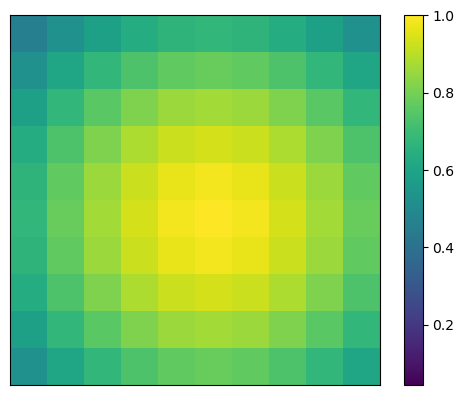

In [9]:
import math
import numpy as np
import torch
def g_kernel(x, mean, sigma):
    return torch.exp(-(x-mean)@(x-mean)/(2*sigma**2))

patch_size = 10
half_hsize = int(patch_size/2)

h = np.empty((2, patch_size, patch_size))
for i in range( patch_size):
    for j in range( patch_size):
        h[:,i,j] = (i,j)

gh = torch.empty(h.shape[1:])
for i in range(h.shape[1]):
    for j in range(h.shape[2]):
        gh[i,j]= g_kernel(torch.from_numpy(h[:,i,j]).to(dtype=torch.float), half_hsize, 8)

h_sum = torch.sum(gh)
W = gh.unsqueeze(0).unsqueeze(0)
import matplotlib.pyplot as plt
plt.imshow(W[0,0,:,:]*W[0,0,:,:],  vmax = 1, vmin = 0.0439)
plt.xticks([])
plt.yticks([])
plt.colorbar()
W_10 = W[0,0,:,:]*W[0,0,:,:]

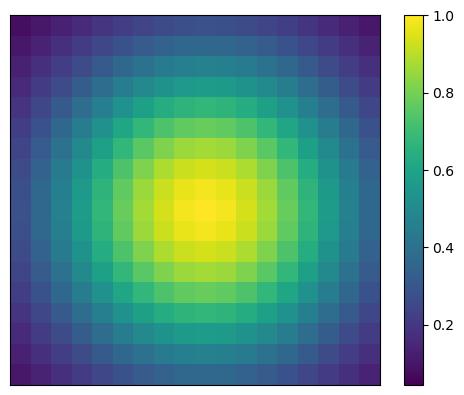

In [10]:
import math
import numpy as np
import torch
def g_kernel(x, mean, sigma):
    return torch.exp(-(x-mean)@(x-mean)/(2*sigma**2))

patch_size = 18
half_hsize = int(patch_size/2)

h = np.empty((2, patch_size, patch_size))
for i in range( patch_size):
    for j in range( patch_size):
        h[:,i,j] = (i,j)

gh = torch.empty(h.shape[1:])
for i in range(h.shape[1]):
    for j in range(h.shape[2]):
        gh[i,j]= g_kernel(torch.from_numpy(h[:,i,j]).to(dtype=torch.float), half_hsize, 8)

h_sum = torch.sum(gh)
W = gh.unsqueeze(0).unsqueeze(0)
import matplotlib.pyplot as plt
plt.imshow(W[0,0,:,:]*W[0,0,:,:],  vmax = 1, vmin = 0.0439)
plt.xticks([])
plt.yticks([])
plt.colorbar()
W_18 = W[0,0,:,:]*W[0,0,:,:]

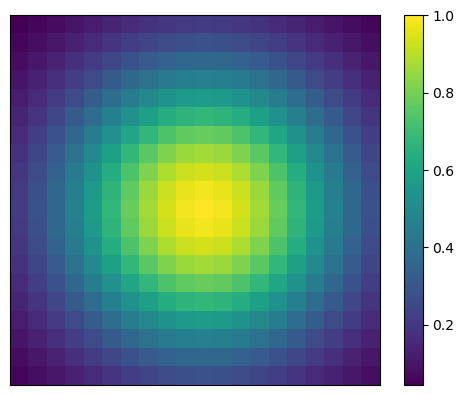

In [11]:
import math
import numpy as np
import torch
def g_kernel(x, mean, sigma):
    return torch.exp(-(x-mean)@(x-mean)/(2*sigma**2))

patch_size = 20
half_hsize = int(patch_size/2)

h = np.empty((2, patch_size, patch_size))
for i in range( patch_size):
    for j in range( patch_size):
        h[:,i,j] = (i,j)

gh = torch.empty(h.shape[1:])
for i in range(h.shape[1]):
    for j in range(h.shape[2]):
        gh[i,j]= g_kernel(torch.from_numpy(h[:,i,j]).to(dtype=torch.float), half_hsize, 8)

h_sum = torch.sum(gh)
W = gh.unsqueeze(0).unsqueeze(0)
import matplotlib.pyplot as plt
plt.imshow(W[0,0,:,:]*W[0,0,:,:], vmax = 1, vmin = 0.0439)
plt.xticks([])
plt.yticks([])
plt.colorbar()
W_20 = W[0,0,:,:]*W[0,0,:,:]

# Visualizing convolutional kernels


In [12]:
def zero_pad_conv_image(conv_matrix, padding_factor):
    w = torch.nn.ZeroPad2d(10-padding_factor)
    return w(conv_matrix)

In [14]:
new_w8 = np.ma.masked_where(zero_pad_conv_image(W_8, 4) == 0, zero_pad_conv_image(W_8, 4))

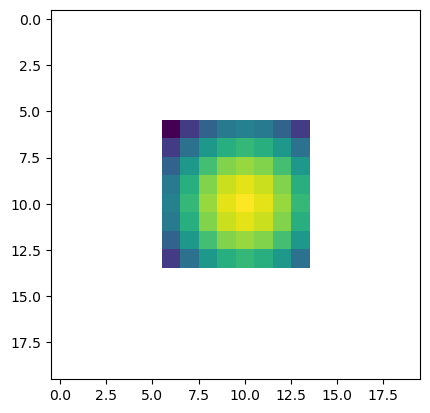

In [15]:
plt.imshow(new_w8)

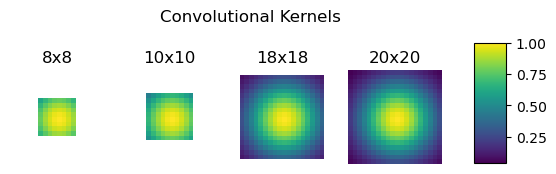

In [23]:
fig, axes = plt.subplots(1, 4) 

kernel_sizes = [8,10,18,20]
kernels = [W_8, W_10, W_18, W_20]

vmin = torch.min(torch.tensor([torch.min(w) for w in kernels]))
vmax = torch.max(torch.tensor([torch.max(w) for w in kernels]))

fig.suptitle('Convolutional Kernels', y=0.72)
fig.patch.set_visible(False)

for i in range(4):
    W = zero_pad_conv_image(kernels[i], int(kernel_sizes[i]/2))
    W = np.ma.masked_where(W == 0, W)
    im = axes[i].imshow(W, vmin = vmin, vmax = vmax)
    axes[i].title.set_text(f"{kernel_sizes[i]}x{kernel_sizes[i]}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].axis('off')
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.4, 0.05, 0.25])
fig.colorbar(im, cax=cbar_ax)
plt.savefig('figures/conv_kernels.png', bbox_inches='tight',dpi=300)
